# 補足実験：直接法の周辺を確かめる

`01_homework_direct_method.ipynb` が宿題そのもの。こちらはその周辺の検証と実験。
どの節も独立に読めるようにしてある。

| 節 | 問い | ノートの対応箇所 |
|---|---|---|
| 1 | 集計ショックをどう消したのか。$u = 0.07$ はどこから来たのか | — |
| 2 | 定常状態はどんな経済なのか。資産分布・MPC・財市場 | — |
| 3 | 差分幅 $\varepsilon$ をどう選ぶか。基準走行はなぜ必要か | 7.6, 7.7 |
| 4 | 直接法はなぜ $O(T^2)$ なのか。どこが重複しているのか | 7.4, 7.5, 8.3 |
| 5 | フェイクニュース法・ライブラリと一致するか | 8章 |
| 6 | 失業保険を変えると何が起きるか | — |

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ks
from ks import DifferenceScheme, Employment

plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=6, suppress=True, linewidth=140)

T = 5
model = ks.KSModel.build()
ss = ks.solve_general_equilibrium(model)
print(f"K = {ss.K:.8f}   r = {ss.prices.r:.8f}   w = {ss.prices.w:.8f}")

K = 11.60936401   r = 0.00999853   w = 2.37449987


---
# 1. 集計ショックをどう消したか

SSJ の定常状態には集計ショック $A$ が存在しない。だが KS の雇用遷移は $A$ に依存する
（好況 $u = 0.04$、不況 $u = 0.10$）。そこで $(A, l)$ の4状態チェーンを
$l$ だけの2状態チェーンに潰す必要がある。

$u$ を決め打ちするのではなく、既存コードのマルコフ連鎖が実際に持っている定常分布を使う:

$$\Pi(l' \mid l) = \frac{\sum_{A, A'} \pi(A, l)\, P(A' \mid A)\, P(l' \mid A, A', l)}{\pi(l)}$$

## 1.1 この式の読み方

やっていることは**条件付き確率の定義そのもの**で、3行で出る。

$$\Pr(l_{t+1}=l' \mid l_t=l)
\ \overset{\text{定義}}{=}\ \frac{\Pr(l_{t+1}=l',\, l_t=l)}{\Pr(l_t=l)}
\ \overset{A\text{ を足し上げ}}{=}\ \frac{\sum_{A,A'}\Pr(A,l,A',l')}{\Pr(l)}
\ \overset{\text{マルコフ性}}{=}\ \frac{\sum_{A,A'}\pi(A,l)P(A'\mid A)P(l'\mid A,A',l)}{\pi(l)}$$

$A$ は観測しないので、可能な $(A, A')$ の組を全部足し上げて消している。
分子は「実際に起きている $l \to l'$ のフロー」、分母は「実際に $l$ にいるストック」。

In [2]:
chains = model.chains

print("集計状態の遷移 P(A'|A)  行 = [不況, 好況]")
display(pd.DataFrame(chains.aggregate, index=["不況", "好況"], columns=["不況'", "好況'"]))

print("これらの確率は既存コード Setting の dur パラメータから出ている。")
print("2状態チェーンで留まる確率 q の期待継続期間は 1/(1-q) なので、目標 D に対し q = (D-1)/D:")
c = model.calibration
for name, dur, meaning in [("dur_good", c.dur_good, "好況の継続期間"),
                           ("dur_bad", c.dur_bad, "不況の継続期間"),
                           ("dur_unemployed_good", c.dur_unemployed_good, "好況時の失業継続期間"),
                           ("dur_unemployed_bad", c.dur_unemployed_bad, "不況時の失業継続期間")]:
    q = (dur - 1) / dur
    print(f"   {name:20s} = {dur:4.1f} ({meaning:12s}) -> ({dur}-1)/{dur} = {q:.6f}"
          f"   検算 1/(1-q) = {1/(1-q):.4f}")

print(f"\n集計状態の定常分布 A_ss     = {chains.aggregate_stationary}")
print(f"(A, l) 同時定常分布         = {chains.joint_stationary}")
print("   [不況&失業, 不況&就業, 好況&失業, 好況&就業]")
print(f"雇用の周辺分布 [失業, 就業] = {chains.employment_marginal}")
print()
print("A を積分した2状態チェーン Pi(l'|l)")
display(pd.DataFrame(chains.employment, index=["失業", "就業"], columns=["失業'", "就業'"]))
print(f"定常失業率 u              = {chains.u_ss:.6f}")
print(f"平均失業継続期間          = {chains.mean_unemployment_duration:.4f} 四半期")

集計状態の遷移 P(A'|A)  行 = [不況, 好況]


,不況',好況'
不況,0.875,0.125
好況,0.125,0.875


これらの確率は既存コード Setting の dur パラメータから出ている。
2状態チェーンで留まる確率 q の期待継続期間は 1/(1-q) なので、目標 D に対し q = (D-1)/D:
   dur_good             =  8.0 (好況の継続期間     ) -> (8.0-1)/8.0 = 0.875000   検算 1/(1-q) = 8.0000
   dur_bad              =  8.0 (不況の継続期間     ) -> (8.0-1)/8.0 = 0.875000   検算 1/(1-q) = 8.0000
   dur_unemployed_good  =  1.5 (好況時の失業継続期間  ) -> (1.5-1)/1.5 = 0.333333   検算 1/(1-q) = 1.5000
   dur_unemployed_bad   =  2.5 (不況時の失業継続期間  ) -> (2.5-1)/2.5 = 0.600000   検算 1/(1-q) = 2.5000

集計状態の定常分布 A_ss     = [0.5 0.5]
(A, l) 同時定常分布         = [0.05 0.45 0.02 0.48]
   [不況&失業, 不況&就業, 好況&失業, 好況&就業]
雇用の周辺分布 [失業, 就業] = [0.07 0.93]

A を積分した2状態チェーン Pi(l'|l)


,失業',就業'
失業,0.507440,0.492560
就業,0.037074,0.962926


定常失業率 u              = 0.070000
平均失業継続期間          = 2.0302 四半期


$A_{ss} = [0.5, 0.5]$ になるのは `dur_good = dur_bad = 8` で好況・不況の期待継続期間が等しく、
遷移行列が対称になるから。その結果 $u = 0.07$、$Z = 1.00$ ちょうどになる。
**この対称性に依存している**ので、`dur_good != dur_bad` なら $Z \ne 1$ になり
正規化を考え直す必要がある。

## 1.2 何を何で混ぜているのか

`p_l_lAA` は実質 **2×2 の行列4枚**（$(A, A')$ の組が4通り）。
どの行列も **行 = 今の雇用状態、列 = 来期の雇用状態**。
$\Pi$ もこれと同じ形で、**この4枚を混ぜて1枚にする**のが上の式。

「重み」とは、4枚をどの比率で混ぜるかという4つの数字（合計1）のこと。
**肝心なのは、行0（失業者）を作るときと行1（就業者）を作るときで重みが違うこと。**

In [3]:
labels = [("不況", "不況"), ("不況", "好況"), ("好況", "不況"), ("好況", "好況")]
matrices = [chains.conditional_employment_matrix(i, j) for i in range(2) for j in range(2)]

print("材料: (A, A') の組ごとの 2x2 雇用遷移行列")
for (a, ap), M in zip(labels, matrices, strict=True):
    print(f"   M[{a}->{ap}] = [[{M[0,0]:.6f}, {M[0,1]:.6f}]   <- 行0 = 今 失業の人")
    print(f"                  [{M[1,0]:.6f}, {M[1,1]:.6f}]]  <- 行1 = 今 就業の人")

w0 = chains.mixing_weights(Employment.UNEMPLOYED)
w1 = chains.mixing_weights(Employment.EMPLOYED)
w_naive = np.array([0.5 * chains.aggregate[i, j] for i in range(2) for j in range(2)])

print("\n重み = 4枚をどの比率で混ぜるか")
display(pd.DataFrame({"行0（今 失業）用": w0, "行1（今 就業）用": w1, "素朴版 pi(A)（共通）": w_naive},
                     index=[f"{a}->{ap}" for a, ap in labels]))
print(f"   合計                : {w0.sum():.6f}  {w1.sum():.6f}  {w_naive.sum():.6f}")
print(f"   うち「今が不況」    : {w0[:2].sum():.6f}  {w1[:2].sum():.6f}  {w_naive[:2].sum():.6f}")
print()
print("失業者は不況に偏在しているので、行0 だけ不況側が重くなる:")
j = chains.joint_stationary
print(f"   失業者のうち不況にいる割合 = {j[0] / chains.employment_marginal[0]:.4f}"
      f"   (不況の頻度は {chains.aggregate_stationary[0]:.2f})")

材料: (A, A') の組ごとの 2x2 雇用遷移行列
   M[不況->不況] = [[0.600000, 0.400000]   <- 行0 = 今 失業の人
                  [0.044444, 0.955556]]  <- 行1 = 今 就業の人
   M[不況->好況] = [[0.250000, 0.750000]   <- 行0 = 今 失業の人
                  [0.016667, 0.983333]]  <- 行1 = 今 就業の人
   M[好況->不況] = [[0.750000, 0.250000]   <- 行0 = 今 失業の人
                  [0.072917, 0.927083]]  <- 行1 = 今 就業の人
   M[好況->好況] = [[0.333333, 0.666667]   <- 行0 = 今 失業の人
                  [0.027778, 0.972222]]  <- 行1 = 今 就業の人

重み = 4枚をどの比率で混ぜるか


,行0（今 失業）用,行1（今 就業）用,素朴版 pi(A)（共通）
不況->不況,0.625000,0.423387,0.4375
不況->好況,0.089286,0.060484,0.0625
好況->不況,0.035714,0.064516,0.0625
好況->好況,0.250000,0.451613,0.4375


   合計                : 1.000000  1.000000  1.000000
   うち「今が不況」    : 0.714286  0.483871  0.500000

失業者は不況に偏在しているので、行0 だけ不況側が重くなる:
   失業者のうち不況にいる割合 = 0.7143   (不況の頻度は 0.50)


## 1.3 「この構成は定義から周辺失業率 $u$ を保存する」の意味

**2つの別々の数字が一致する**という主張。

| | 中身 | |
|---|---|---|
| 潰す前 | 元の4状態経済の平均失業率 $\pi(l = \text{失業})$ | 0.07 |
| 潰した後 | $\Pi$ を**単独の**マルコフ連鎖として回したときの失業率 | ? |

一般に「平均を取ってから不動点を求める」と「不動点を求めてから平均を取る」は違う。
実際、重みを共通の $\pi(A) = [0.5, 0.5]$ にすると壊れる。

In [4]:
Pi_naive = np.zeros((2, 2))
for row in range(2):
    for k, M in enumerate(matrices):
        Pi_naive[row] += w_naive[k] * M[row]

print("正しい Pi =\n", model.Pi)
print("素朴版    =\n", Pi_naive)
print(f"\n-> 行1（就業者）はほぼ同じ {model.Pi[1,0]:.6f} vs {Pi_naive[1,0]:.6f}")
print(f"   行0（失業者）が大きくずれる {model.Pi[0,0]:.6f} vs {Pi_naive[0,0]:.6f}")
print()
print(f"正しい Pi の定常失業率 = {ks.stationary_distribution(model.Pi)[0]:.6f}"
      f"   (周辺 pi(l=失業) = {chains.employment_marginal[0]:.6f} と一致)")
print(f"素朴版の定常失業率     = {ks.stationary_distribution(Pi_naive)[0]:.6f}   <- 0.07 から外れる")

正しい Pi =
 [[0.50744  0.49256 ]
 [0.037074 0.962926]]
素朴版    =
 [[0.470833 0.529167]
 [0.037196 0.962804]]

-> 行1（就業者）はほぼ同じ 0.037074 vs 0.037196
   行0（失業者）が大きくずれる 0.507440 vs 0.470833

正しい Pi の定常失業率 = 0.070000   (周辺 pi(l=失業) = 0.070000 と一致)
素朴版の定常失業率     = 0.065676   <- 0.07 から外れる


**なぜ正しい重みだと成り立つのか。** $\Pi$ の定義の分母を払うと

$$\pi(l)\,\Pi(l'\mid l) = \text{元の経済で実際に起きているフロー}$$

元の経済は定常状態なので流入と流出が釣り合っている。つまり

$$\underbrace{\pi(u)\,\Pi(e\mid u)}_{\text{失業}\to\text{就業}} = \underbrace{\pi(e)\,\Pi(u\mid e)}_{\text{就業}\to\text{失業}}$$

2状態マルコフ連鎖の定常分布は**まさにこの式で決まる**ので、$[\pi(u), \pi(e)]$ が
$\Pi$ の定常分布になる。「定義から」というのは、$\Pi$ を「フロー ÷ ストック」として
定義した時点でこの性質が自動的についてくる、という意味。

In [5]:
marg = chains.employment_marginal
print("フロー均衡（2状態ではこれが定常条件そのもの）")
print(f"   失業 -> 就業:  pi(u) * Pi(e|u) = {marg[0]:.6f} * {model.Pi[0,1]:.6f} = {marg[0]*model.Pi[0,1]:.8f}")
print(f"   就業 -> 失業:  pi(e) * Pi(u|e) = {marg[1]:.6f} * {model.Pi[1,0]:.6f} = {marg[1]*model.Pi[1,0]:.8f}")
print(f"   差 = {marg[0]*model.Pi[0,1] - marg[1]*model.Pi[1,0]:.3e}")

raw_ue = sum(chains.joint_stationary[2*i+0] * chains.aggregate[i, jj]
             * chains.employment_given_A[2*i+0, 2*jj+1] for i in range(2) for jj in range(2))
print(f"\n   元の4状態経済で失業->就業のフローを直接数えると {raw_ue:.8f}  (一致)")

フロー均衡（2状態ではこれが定常条件そのもの）
   失業 -> 就業:  pi(u) * Pi(e|u) = 0.070000 * 0.492560 = 0.03447917
   就業 -> 失業:  pi(e) * Pi(u|e) = 0.930000 * 0.037074 = 0.03447917
   差 = 3.317e-15

   元の4状態経済で失業->就業のフローを直接数えると 0.03447917  (一致)


## 1.4 近似になっている点

元の KS 経済では $l$ 単独は厳密には**マルコフではない**（$A_t$ を知っていれば
$l_{t+1}$ の予測が改善する）。$\Pi$ は1期先の条件付き分布を定常分布のもとで平均的に
再現するが、2期先以降はずれる。

In [6]:
P2 = np.linalg.matrix_power(chains.joint, 2)
true_2step = np.zeros((2, 2))
for il in range(2):
    for ia in range(2):
        for ja in range(2):
            for jl in range(2):
                true_2step[il, jl] += chains.joint_stationary[2*ia+il] * P2[2*ia+il, 2*ja+jl]
true_2step /= marg[:, None]

print("真の P(l_{t+2} | l_t) =\n", true_2step)
print("Pi を2乗したもの      =\n", model.Pi @ model.Pi)
print(f"最大差 = {np.max(np.abs(true_2step - model.Pi @ model.Pi)):.3e}")
print()
print("-> 真の l の方が失業が持続しやすい。A の持続性（0.875）が失業状態に持続性を")
print("   追加で与えているのに、それが2期目以降で落ちているため。")
print()
print("経済的には「不況では失業リスクが上がる」という連動が家計ブロックから消えている。")
print("HANK で重要な増幅メカニズムなので、必要なら SSJ 側で Pi 自体を入力として動かす。")

真の P(l_{t+2} | l_t) =
 [[0.282631 0.717369]
 [0.053995 0.946005]]
Pi を2乗したもの      =
 [[0.275757 0.724243]
 [0.054513 0.945487]]
最大差 = 6.874e-03

-> 真の l の方が失業が持続しやすい。A の持続性（0.875）が失業状態に持続性を
   追加で与えているのに、それが2期目以降で落ちているため。

経済的には「不況では失業リスクが上がる」という連動が家計ブロックから消えている。
HANK で重要な増幅メカニズムなので、必要なら SSJ 側で Pi 自体を入力として動かす。


---
# 2. 定常状態はどんな経済か

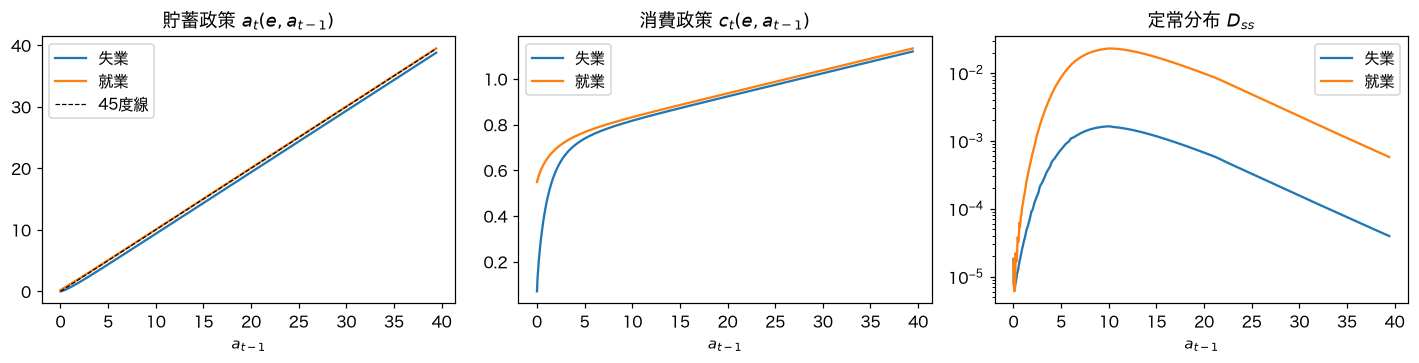

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
zoom = model.a_grid <= 40

ax[0].plot(model.a_grid[zoom], ss.a[Employment.UNEMPLOYED][zoom], label="失業")
ax[0].plot(model.a_grid[zoom], ss.a[Employment.EMPLOYED][zoom], label="就業")
ax[0].plot(model.a_grid[zoom], model.a_grid[zoom], "k--", lw=0.8, label="45度線")
ax[0].set_title("貯蓄政策 $a_t(e, a_{t-1})$"); ax[0].set_xlabel("$a_{t-1}$"); ax[0].legend()

ax[1].plot(model.a_grid[zoom], ss.c[Employment.UNEMPLOYED][zoom], label="失業")
ax[1].plot(model.a_grid[zoom], ss.c[Employment.EMPLOYED][zoom], label="就業")
ax[1].set_title("消費政策 $c_t(e, a_{t-1})$"); ax[1].set_xlabel("$a_{t-1}$"); ax[1].legend()

ax[2].plot(model.a_grid[zoom], ss.D[Employment.UNEMPLOYED][zoom], label="失業")
ax[2].plot(model.a_grid[zoom], ss.D[Employment.EMPLOYED][zoom], label="就業")
ax[2].set_yscale("log"); ax[2].set_title("定常分布 $D_{ss}$"); ax[2].set_xlabel("$a_{t-1}$"); ax[2].legend()

plt.tight_layout(); plt.show()

In [8]:
def wealth_statistics(model, ss):
    a_all = np.tile(model.a_grid, model.n_e)
    w_all = ss.D.ravel()
    order = np.argsort(a_all)
    a_s, w_s = a_all[order], w_all[order]
    cum_pop = np.cumsum(w_s)
    share = np.cumsum(w_s * a_s) / np.sum(w_s * a_s)
    gini = 1.0 - np.sum(w_s * (np.concatenate(([0.0], share[:-1])) + share))
    return cum_pop, share, gini

cum_pop, share, gini = wealth_statistics(model, ss)
for q in (0.01, 0.10, 0.20):
    print(f"上位 {q:>4.0%} が保有する資産の割合 = {1 - np.interp(1 - q, cum_pop, share):.3f}")
print(f"資産のジニ係数                = {gini:.3f}")
print()
print("-> 米国データでは上位1%が資産の約3割、ジニは 0.8 程度。まったく届かない。")
print("   beta*(1+r) が 1 に近く全員が似た目標資産に向かうため、資産分布が平等になりすぎる。")
print("   KS(1998) の既知の弱点。")

上位   1% が保有する資産の割合 = 0.033
上位  10% が保有する資産の割合 = 0.219
上位  20% が保有する資産の割合 = 0.370
資産のジニ係数                = 0.287

-> 米国データでは上位1%が資産の約3割、ジニは 0.8 程度。まったく届かない。
   beta*(1+r) が 1 に近く全員が似た目標資産に向かうため、資産分布が平等になりすぎる。
   KS(1998) の既知の弱点。


In [9]:
Y = model.output(ss.K)
walras = Y - ss.C - model.calibration.delta * ss.K
print(f"財市場  Y - C - delta*K = {walras:+.6f}")
print(f"        = -u * 失業保険 = {-model.u_ss * model.calibration.unemployment_insurance:+.6f}")
print()
print("元の 8_2_krusell_and_smith.py では失業保険が課税で賄われていない（純粋な移転）ため、")
print("資源制約がその分だけずれる。家計ブロックのヤコビアン（部分均衡）には影響しないが、")
print("第10・11章で一般均衡に閉じるときは税で賄うか、Walras の法則の点検を緩める必要がある。")

財市場  Y - C - delta*K = -0.004900
        = -u * 失業保険 = -0.004900

元の 8_2_krusell_and_smith.py では失業保険が課税で賄われていない（純粋な移転）ため、
資源制約がその分だけずれる。家計ブロックのヤコビアン（部分均衡）には影響しないが、
第10・11章で一般均衡に閉じるときは税で賄うか、Walras の法則の点検を緩める必要がある。


In [10]:
J = ks.jacobian_direct(model, ss, T=T, scheme=DifferenceScheme.CENTRAL)
print(f"労働所得1単位あたりの MPC   dC_0/dw_0 / N     = {J.C_w[0,0] / model.N:.5f}")
print(f"資本所得1単位あたりの MPC   dC_0/dr_0 / K_ss  = {J.C_r[0,0] / ss.K:.5f}")
print(f"参考: 恒常所得仮説なら r/(1+r) = {ss.prices.r / (1 + ss.prices.r):.5f}")
print()
print("-> どちらも 1% 程度。beta = 0.99 が非忍耐性の境界に張り付いているので家計は")
print("   きわめて忍耐強く、所得ショックをほとんど消費に回さない。")
print("   HANK 文献で高い MPC を出したいなら beta を下げるか流動性制約を強める必要がある。")

労働所得1単位あたりの MPC   dC_0/dw_0 / N     = 0.01246
資本所得1単位あたりの MPC   dC_0/dr_0 / K_ss  = 0.01126
参考: 恒常所得仮説なら r/(1+r) = 0.00990

-> どちらも 1% 程度。beta = 0.99 が非忍耐性の境界に張り付いているので家計は
   きわめて忍耐強く、所得ショックをほとんど消費に回さない。
   HANK 文献で高い MPC を出したいなら beta を下げるか流動性制約を強める必要がある。


---
# 3. 差分幅と基準走行（ノート 7.6, 7.7）

$$\text{片側}: \frac{h(X^{s,+}) - Y^0}{\varepsilon} = J_{:,s} + O(\varepsilon)
\qquad
\text{中央}: \frac{h(X^{s,+}) - h(X^{s,-})}{2\varepsilon} = J_{:,s} + O(\varepsilon^2)$$

$\varepsilon$ が大きすぎると一次近似の外に出る。小さすぎると丸め誤差と解法の停止誤差を
$\varepsilon$ で割ってしまう。

,片側差分の誤差,中央差分の誤差
eps,,
0.100000,2.342e-01,2.226e-02
0.010000,2.580e-02,8.505e-04
0.001000,2.607e-03,7.132e-06
0.000100,2.621e-04,3.182e-08
0.000010,2.621e-05,1.599e-09
0.000001,2.622e-06,0.000e+00
0.000000,2.807e-07,1.776e-08
0.000000,4.619e-07,1.714e-07


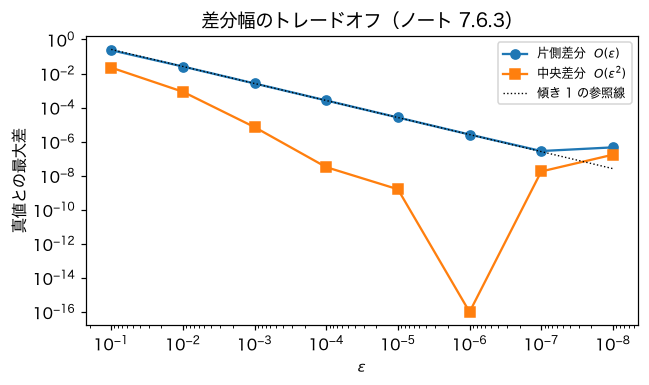

In [11]:
truth = ks.jacobian_direct(model, ss, T=T, eps=1e-6, scheme=DifferenceScheme.CENTRAL)

rows = []
for eps in (1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8):
    one = ks.jacobian_direct(model, ss, T=T, eps=eps, scheme=DifferenceScheme.ONE_SIDED)
    two = ks.jacobian_direct(model, ss, T=T, eps=eps, scheme=DifferenceScheme.CENTRAL)
    rows.append({"eps": eps, "片側差分の誤差": one.max_difference(truth),
                 "中央差分の誤差": two.max_difference(truth)})
table = pd.DataFrame(rows).set_index("eps")
display(table.style.format("{:.3e}"))

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.loglog(table.index, table["片側差分の誤差"], "o-", label=r"片側差分  $O(\varepsilon)$")
ax.loglog(table.index, table["中央差分の誤差"].clip(lower=1e-16), "s-", label=r"中央差分  $O(\varepsilon^2)$")
ax.loglog(table.index, 2.6 * table.index, "k:", lw=0.9, label="傾き 1 の参照線")
ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel("真値との最大差")
ax.set_title("差分幅のトレードオフ（ノート 7.6.3）"); ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout(); plt.show()

片側差分の誤差はきれいに $\varepsilon$ に比例。中央差分は $\varepsilon^2$ で落ちるが、
$\varepsilon$ を小さくしすぎると丸め誤差が効いて**逆に悪化する**。

## 3.1 基準走行 $Y^0$ を差し引く効果

わざと定常分布を甘く解いた定常状態を作って比べる。

In [12]:
# 反復を 1e-8 で打ち切った甘い定常分布を作る
lottery = ks.asset_lottery(model.a_grid, ss.a)
D_sloppy = np.outer(ks.stationary_distribution(model.Pi), np.full(model.n_a, 1 / model.n_a))
for iteration in range(1, 500_001):
    D_new = ks.forward_step(D_sloppy, model.Pi, lottery)
    if iteration % 100 == 0 and np.max(np.abs(D_new - D_sloppy)) < 1e-8:
        D_sloppy = D_new
        break
    D_sloppy = D_new

ss_sloppy = ss.model_copy(update={"D": D_sloppy, "K": float(np.vdot(D_sloppy, ss.a))})
print(f"甘い定常状態: 反復 {iteration} 回で停止,  K = {ss_sloppy.K:.8f}  (厳密解 {ss.K:.8f})")

r_ss = np.full(T, ss.prices.r); w_ss = np.full(T, ss.prices.w)
base_sloppy = ks.simulate_transition(model, ss_sloppy, r_ss, w_ss)
print("\n甘い定常状態での基準走行 K^0_t - K_ss:")
print("   ", "  ".join(f"{v:+.3e}" for v in base_sloppy.K - ss_sloppy.K))
print("これを eps = 1e-4 で割ると:", "  ".join(f"{v:+.3e}" for v in (base_sloppy.K - ss_sloppy.K) / 1e-4))

# Y^0 を引く（正しい）vs Y_ss を引く（悪い）
J_sloppy = ks.jacobian_direct(model, ss_sloppy, T=T, eps=1e-4)
r_pert = r_ss.copy(); r_pert[3] += 1e-4
pert_sloppy = ks.simulate_transition(model, ss_sloppy, r_pert, w_ss)
column_bad = (pert_sloppy.K - ss_sloppy.K) / 1e-4

print("\n第3列の比較（甘い定常状態のもとで）")
print("  Y^0 を差し引いた  :", np.array2string(J_sloppy.K_r[:, 3], precision=6))
print("  Y_ss を差し引いた :", np.array2string(column_bad, precision=6))
print("  真値              :", np.array2string(truth.K_r[:, 3], precision=6))
print()
print(f"  Y^0 版の誤差  = {np.max(np.abs(J_sloppy.K_r[:, 3] - truth.K_r[:, 3])):.3e}")
print(f"  Y_ss 版の誤差 = {np.max(np.abs(column_bad - truth.K_r[:, 3])):.3e}")
print()
print("-> 基準走行を差し引けば、定常状態の解き方が甘くても共通誤差が相殺される。")

甘い定常状態: 反復 22800 回で停止,  K = 11.62880115  (厳密解 11.60936401)

甘い定常状態での基準走行 K^0_t - K_ss:
    -6.253e-13  -9.475e-06  -1.895e-05  -2.841e-05  -3.787e-05
これを eps = 1e-4 で割ると: -6.253e-09  -9.475e-02  -1.895e-01  -2.841e-01  -3.787e-01

第3列の比較（甘い定常状態のもとで）
  Y^0 を差し引いた  : [ 0.677679  1.362259  2.053856 13.546513 13.525353]
  Y_ss を差し引いた : [ 0.677679  1.267506  1.864396 13.262392 13.146615]
  真値              : [ 0.677719  1.362339  2.053977 13.527187 13.50601 ]

  Y^0 版の誤差  = 1.934e-02
  Y_ss 版の誤差 = 3.594e-01

-> 基準走行を差し引けば、定常状態の解き方が甘くても共通誤差が相殺される。


---
# 4. 計算量と重複（ノート 7.4, 7.5, 8.3）

一つの入力について、各列 $s$ を求めるたびに後ろ向き $\approx T$ 回・前向き $\approx T$ 回。
列は $T$ 本あるので $T \times T = O(T^2)$。

## 4.1 時間並進補題

時点 $s = 10$ のニュースに対する時点 $t = 3$ の**政策反応**と、
$s = 11$ のニュースに対する $t = 4$ の政策反応は、どちらも「ショックまで7期」なので同じもの。
定常状態のまわりでは、家計の動的問題はカレンダー時点ではなくショックまでの距離だけに依存する。

ここで言っているのは**政策関数の反応**（グリッド上のベクトル）であって
ヤコビアンの要素 $J_{t,s}$ ではない。$J_{t,s}$ は政策反応を分布 $D_t$ で集計したもので、
その $D_t$ はショック以降ずれ続けるので $J_{t,s} \ne J_{t+1,s+1}$ になる。

In [13]:
h = 1e-6
T_long = 20

def policy_response(s: int, T_: int = T_long):
    "時点 s の金利ニュースに対する、各時点の政策関数の反応 da_t/dr_s"
    r_path = np.full(T_, ss.prices.r); r_path[s] += h
    w_path = np.full(T_, ss.prices.w)
    path = ks.simulate_transition(model, ss, r_path, w_path, store_internals=True)
    return (path.a - ss.a) / h

da10, da11 = policy_response(10), policy_response(11)

print("時間並進補題（ノート 8.3）: 政策反応は「ショックまでの距離」だけに依存する")
print(f"    {'距離':>6} {'max|差|':>12} {'反応の大きさ':>14} {'相対差':>10}")
for k in (7, 5, 3, 1, 0):
    lhs, rhs = da10[10 - k], da11[11 - k]
    d, scale = np.max(np.abs(lhs - rhs)), np.max(np.abs(lhs))
    print(f"    {k:>6} {d:12.3e} {scale:14.3e} {d/scale:10.2e}")

resid = np.max(np.abs(ks.backward_egm(model.Pi @ ss.Va, model.a_grid, ss.y,
                                      ss.prices.r, model.calibration.beta,
                                      model.calibration.eis).a - ss.a))
print(f"\n-> 残る絶対差は、定常政策の不動点残差 max|a' - a| = {resid:.2e} を h = {h:g} で")
print(f"   割った {resid/h:.2e} と一致する。補題の破れではなく有限精度の反映。")
print("   直接法は列ごとにこの計算を丸ごとやり直している（ノート 7.5 の重複）。")

時間並進補題（ノート 8.3）: 政策反応は「ショックまでの距離」だけに依存する
        距離       max|差|         反応の大きさ        相対差
         7    1.705e-07      6.780e-01   2.52e-07
         5    1.705e-07      6.916e-01   2.47e-07
         3    1.705e-07      7.056e-01   2.42e-07
         1    1.528e-07      7.201e-01   2.12e-07
         0    1.554e-07      2.970e+02   5.23e-10

-> 残る絶対差は、定常政策の不動点残差 max|a' - a| = 1.79e-13 を h = 1e-06 で
   割った 1.79e-07 と一致する。補題の破れではなく有限精度の反映。
   直接法は列ごとにこの計算を丸ごとやり直している（ノート 7.5 の重複）。


In [14]:
J20 = ks.jacobian_direct(model, ss, T=T_long, eps=1e-6, scheme=DifferenceScheme.CENTRAL).K_r

print("一方、ヤコビアンの要素は対角方向にずらすと一致しない（分布 D_t がずれ続けるから）:")
for t, s in [(3, 10), (4, 11), (5, 12), (6, 13)]:
    print(f"    J[{t:2d}, {s:2d}] = {J20[t, s]:.10f}")

F = J20.copy()
F[1:, 1:] -= J20[:-1, :-1]
print("\nその差 F[t, s] = J[t, s] - J[t-1, s-1] がフェイクニュース行列:")
for t, s in [(3, 10), (4, 11), (5, 12), (6, 13)]:
    print(f"    F[{t:2d}, {s:2d}] = {F[t, s]:.10f}")
print()
print("第8章の要点は、この F が")
print("      F[0, s] = curlyY[s]                （時点 s のニュースへの時点0 の集計反応）")
print("      F[t, s] = curlyE[t-1] . curlyD[s]  （t >= 1）")
print("と分解できること。curlyY と curlyD は後ろ向き T 回、curlyE は定常遷移行列を T 回")
print("かけるだけで得られるので、高価な計算は O(T) 回で済む。")

一方、ヤコビアンの要素は対角方向にずらすと一致しない（分布 D_t がずれ続けるから）:
    J[ 3, 10] = 2.5196735898
    J[ 4, 11] = 3.1263259048
    J[ 5, 12] = 3.7240196233
    J[ 6, 13] = 4.3129198737

その差 F[t, s] = J[t, s] - J[t-1, s-1] がフェイクニュース行列:
    F[ 3, 10] = 0.6157809374
    F[ 4, 11] = 0.6066523150
    F[ 5, 12] = 0.5976937185
    F[ 6, 13] = 0.5889002503

第8章の要点は、この F が
      F[0, s] = curlyY[s]                （時点 s のニュースへの時点0 の集計反応）
      F[t, s] = curlyE[t-1] . curlyD[s]  （t >= 1）
と分解できること。curlyY と curlyD は後ろ向き T 回、curlyE は定常遷移行列を T 回
かけるだけで得られるので、高価な計算は O(T) 回で済む。


,直接法 (秒),fake news (秒),比
T,,,
5,0.0060,0.0031,1.9x
10,0.0207,0.0042,4.9x
20,0.0794,0.0087,9.2x
40,0.3111,0.0166,18.7x
80,1.2324,0.0345,35.7x


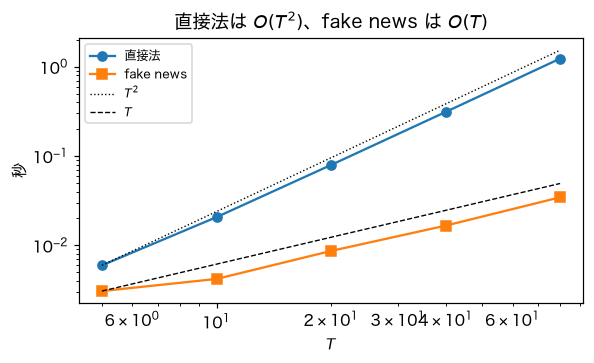

In [15]:
rows = []
for T_ in (5, 10, 20, 40, 80):
    t0 = time.perf_counter(); ks.jacobian_direct(model, ss, T=T_); t_dir = time.perf_counter() - t0
    t0 = time.perf_counter(); ks.jacobian_fake_news(model, ss, T=T_); t_fn = time.perf_counter() - t0
    rows.append({"T": T_, "直接法 (秒)": t_dir, "fake news (秒)": t_fn, "比": t_dir / t_fn})
timing = pd.DataFrame(rows).set_index("T")
display(timing.style.format({"直接法 (秒)": "{:.4f}", "fake news (秒)": "{:.4f}", "比": "{:.1f}x"}))

fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.loglog(timing.index, timing["直接法 (秒)"], "o-", label="直接法")
ax.loglog(timing.index, timing["fake news (秒)"], "s-", label="fake news")
ax.loglog(timing.index, timing["直接法 (秒)"].iloc[0] * (timing.index / 5.0) ** 2, "k:", lw=0.9, label="$T^2$")
ax.loglog(timing.index, timing["fake news (秒)"].iloc[0] * (timing.index / 5.0), "k--", lw=0.9, label="$T$")
ax.set_xlabel("$T$"); ax.set_ylabel("秒"); ax.legend(fontsize=8)
ax.set_title("直接法は $O(T^2)$、fake news は $O(T)$")
plt.tight_layout(); plt.show()

---
# 5. フェイクニュース法・ライブラリとの突き合わせ

`ks.ssj` は `sequence_jacobian` に依存する（`.venv` が必要）。
HetBlock の書き方は自作の `backward_egm` とほぼ一行ずつ対応する:

```python
@het(exogenous='Pi', policy='a', backward='Va', backward_init=hh_init)
def hh(Va_p, a_grid, y, r, beta, eis):
    uc_nextgrid = beta * Va_p                  # Va_p = E_t[Va_{t+1}] は HetBlock が用意
    c_nextgrid  = uc_nextgrid ** (-eis)
    coh = (1 + r) * a_grid[np.newaxis, :] + y[:, np.newaxis]
    a = interpolate_y(c_nextgrid + a_grid, coh, a_grid)
    setmin(a, a_grid[0])
    c = coh - a
    Va = (1 + r) * c ** (-1 / eis)
    return Va, a, c
```

違いは $\Pi \cdot V_{a,t+1}$ の期待計算だけで、それは HetBlock が代行する。

**注意**: sequence-jacobian は `return` 文に書いた**変数名**を出力名として読み取るので、
式をそのまま返してはいけない（必ず `return Va` のように名前付きの変数を返す）。

In [16]:
import ks.ssj as L

ss_lib_loose = L.solve_steady_state(model, ss.prices, strict=False)   # ライブラリの既定 tol
ss_lib = L.solve_steady_state(model, ss.prices, strict=True)          # 締めた tol

print(f"自作版            K = {ss.K:.10f}")
print(f"SSJ 既定 tol      A = {ss_lib_loose['A']:.10f}   誤差 = {ss_lib_loose['A'] - ss.K:+.3e}")
print(f"SSJ 締めた tol    A = {ss_lib['A']:.10f}   誤差 = {ss_lib['A'] - ss.K:+.3e}")
print()
print(f"政策の差 max|a_ssj - a_自作| = {np.max(np.abs(ss_lib.internals['hh']['a'] - ss.a)):.3e}")
print(f"分布の差 max|D_ssj - D_自作| = {np.max(np.abs(ss_lib.internals['hh']['D'] - ss.D)):.3e}")
print()
print("既定 tol だと 1e-4 ほどずれるのは、beta*(1+r) = "
      f"{model.calibration.beta * (1 + ss.prices.r):.8f} が 1 に極端に近く、")
print("分布の前向き反復が「見かけ上収束したのにまだ真の定常分布から遠い」状態になりやすいため。")
print("自作版は定常分布を反復ではなく線形方程式 D = Λ'D で直接解いている。")

自作版            K = 11.6093640145
SSJ 既定 tol      A = 11.6095259727   誤差 = +1.620e-04
SSJ 締めた tol    A = 11.6093641705   誤差 = +1.560e-07

政策の差 max|a_ssj - a_自作| = 9.538e-11
分布の差 max|D_ssj - D_自作| = 1.790e-10

既定 tol だと 1e-4 ほどずれるのは、beta*(1+r) = 0.99989854 が 1 に極端に近く、
分布の前向き反復が「見かけ上収束したのにまだ真の定常分布から遠い」状態になりやすいため。
自作版は定常分布を反復ではなく線形方程式 D = Λ'D で直接解いている。


In [17]:
ss_from_lib = L.steady_state_to_ks(ss_lib)   # 同じ定常状態の上で比べるため

J_direct_one = ks.jacobian_direct(model, ss, T=T, scheme=DifferenceScheme.ONE_SIDED)
J_direct_two = ks.jacobian_direct(model, ss, T=T, scheme=DifferenceScheme.CENTRAL)
J_fn         = ks.jacobian_fake_news(model, ss, T=T)
J_at_lib     = ks.jacobian_direct(model, ss_from_lib, T=T, scheme=DifferenceScheme.ONE_SIDED)

J_lib_fn_two = L.library_jacobians(ss_lib, T=T, twosided=True)
J_lib_fn_one = L.library_jacobians(ss_lib, T=T, twosided=False)
J_lib_direct = L.direct_jacobians_via_library(ss_lib, T=T, subtract_baseline=True)
J_lib_direct_nobase = L.direct_jacobians_via_library(ss_lib, T=T, subtract_baseline=False)

print("4本すべての最大差")
print(f"  自作 直接法(中央)    vs ライブラリ fake news(中央) : {J_direct_two.max_difference(J_lib_fn_two):.3e}")
print(f"  自作 fake news(中央) vs ライブラリ fake news(中央) : {J_fn.max_difference(J_lib_fn_two):.3e}")
print(f"  自作 直接法(片側)    vs ライブラリ 直接法(片側)     : {J_at_lib.max_difference(J_lib_direct):.3e}"
      "   <- 同じ定常状態なら機械精度")
print(f"  同上、基準走行を差し引かない場合                    : {J_at_lib.max_difference(J_lib_direct_nobase):.3e}"
      "   <- ノート 7.7")
print()
print(f"  ライブラリ fake news 片側 vs 中央                  : {J_lib_fn_one.max_difference(J_lib_fn_two):.3e}")

4本すべての最大差
  自作 直接法(中央)    vs ライブラリ fake news(中央) : 1.738e-07
  自作 fake news(中央) vs ライブラリ fake news(中央) : 1.550e-07
  自作 直接法(片側)    vs ライブラリ 直接法(片側)     : 0.000e+00   <- 同じ定常状態なら機械精度
  同上、基準走行を差し引かない場合                    : 3.456e-06   <- ノート 7.7

  ライブラリ fake news 片側 vs 中央                  : 2.649e-04


### 引っかかりやすい2点

**① ライブラリの `.jacobian()` も有限差分である。** フェイクニュース・アルゴリズムが省くのは
「列ごとに同じ後ろ向き・前向き計算を繰り返す重複」であって、有限差分そのものではない。
ただし微分する対象が違う:

| | 微分する対象 | 誤差の入り方 |
|---|---|---|
| 直接法 | **経路全体の写像** $H$ | 素直に $O(\varepsilon)$ / $O(\varepsilon^2)$ |
| fake news | **1期分の後ろ向きステップ** | その誤差が対角方向の累積を通じて $J$ 全体に伝わる |

そのため既定の片側差分 $h = 10^{-4}$ だと、`.jacobian()` は直接法（中央差分）と
$2.6 \times 10^{-4}$ ずれる。**突き合わせるときは `twosided=True` にすること。**

**② `impulse_nonlinear` は「$Y_{ss}$ からの偏差」を返す。** 「基準走行 $Y^0$ からの偏差」
ではない。直接法に使うならゼロショックの走行を1本流して差し引く（上の表の4行目）。

In [18]:
# 一般均衡の定常状態もライブラリに解かせる（第10・11章の入口）
ss_ge = L.solve_general_equilibrium_with_library(model)
print(f"ライブラリ GE:  K = {ss_ge['K']:.8f}   r = {ss_ge['r']:.8f}   w = {ss_ge['w']:.8f}")
print(f"自作版の二分法との差 |dK| = {abs(ss_ge['K'] - ss.K):.3e}")
print()
print("資産需要曲線はこの辺りでほぼ垂直（K = 11.58 で A = 20.4, K = 11.65 で A = 8.5）。")
print(f"beta = 0.99 の KS(1998) 設定が非忍耐性の境界 r = 1/beta - 1 = "
      f"{model.calibration.r_impatience_bound:.6f} に張り付いているため。")
print(f"brentq のブラケット下限は発散点 K = {model.K_impatience_bound:.4f} より上に取る必要がある。")

ライブラリ GE:  K = 11.60936398   r = 0.00999853   w = 2.37449987
自作版の二分法との差 |dK| = 3.508e-08

資産需要曲線はこの辺りでほぼ垂直（K = 11.58 で A = 20.4, K = 11.65 で A = 8.5）。
beta = 0.99 の KS(1998) 設定が非忍耐性の境界 r = 1/beta - 1 = 0.010101 に張り付いているため。
brentq のブラケット下限は発散点 K = 11.5564 より上に取る必要がある。


---
# 6. 失業保険を変えると何が起きるか

`unemployment_insurance = 0.07` は既存コードの `replicate_model = 0` の値。
$w$ に比例しない**水準**で、就業者の労働所得 $w \bar l = 0.777$ に対して代替率 9%。

In [19]:
rows = []
for ui in (0.02, 0.07, 0.15, 0.30, 0.60):
    m = ks.KSModel.build(ks.KSCalibration(unemployment_insurance=ui))
    s = ks.solve_general_equilibrium(m)
    j = ks.jacobian_direct(m, s, T=T, scheme=DifferenceScheme.CENTRAL)
    _, _, g = wealth_statistics(m, s)
    rows.append({"UI": ui, "代替率": ui / (s.prices.w * m.calibration.lbar),
                 "K": s.K, "r": s.prices.r, "C": s.C,
                 "MPC(w)": j.C_w[0, 0] / m.N, "J^Kr[0,0]": j.K_r[0, 0], "ジニ": g})
display(pd.DataFrame(rows).set_index("UI").style.format(
    {"代替率": "{:.3f}", "K": "{:.4f}", "r": "{:.6f}", "C": "{:.4f}",
     "MPC(w)": "{:.4f}", "J^Kr[0,0]": "{:.4f}", "ジニ": "{:.3f}"}))

print(f"参考: 1/beta - 1 = {model.calibration.r_impatience_bound:.6f}")

,代替率,K,r,C,MPC(w),"J^Kr[0,0]",ジニ
UI,,,,,,,
0.020000,0.026,11.6217,0.009975,0.8399,0.0128,11.4873,0.270
0.070000,0.090,11.6094,0.009999,0.8433,0.0125,11.4787,0.287
0.150000,0.193,11.5945,0.010027,0.8488,0.0120,11.4681,0.313
0.300000,0.387,11.5761,0.010063,0.8591,0.0114,11.4550,0.367
0.600000,0.774,11.5594,0.010095,0.8799,0.0106,11.4430,0.533


参考: 1/beta - 1 = 0.010101


読みどころが2つ。

**① $K$ と $r$ がほとんど動かない。** 代替率を 3% から 77% まで振っても $K$ は 0.5% しか
変わらない。$r$ が非忍耐性の境界に張り付いていて、予備的貯蓄動機が弱まっても金利が
それ以上上がれず、$K$ が動く余地がないため。

**② 失業保険を手厚くすると資産ジニが上がる。** 直感に反するようだが、社会保険が
貧困層の予備的貯蓄をクラウドアウトするため。失業しても困らないなら緩衝在庫を持つ
必要がなく、失業者は資産ゼロ付近に張り付く一方、忍耐強い層は変わらず蓄積を続ける。
消費の不平等は逆に下がる。